In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Membuat data sintetis: 300 titik, 4 kelompok alami.
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

# --- K-Means ---
# Membagi data ke 4 cluster berdasarkan jarak ke centroid terdekat.
kmeans = KMeans(n_clusters=4, random_state=42)
labels_k = kmeans.fit_predict(X)  # fit + langsung dapatkan label cluster
print("Inertia:", round(kmeans.inertia_, 2))          # total jarak ke centroid (makin kecil makin baik)
print("Silhouette:", round(silhouette_score(X, labels_k), 3))  # -1 s/d 1 (makin tinggi makin baik)

# --- Hierarchical ---
# Menggabungkan titik-titik terdekat secara bertahap dari bawah ke atas.
agg = AgglomerativeClustering(n_clusters=4)
labels_h = agg.fit_predict(X)
print("Silhouette Hierarchical:", round(silhouette_score(X, labels_h), 3))

Inertia: 564.91
Silhouette: 0.792
Silhouette Hierarchical: 0.792


## Clustering Menggunakan K-Means pada Dataset Iris
#Tujuan
Tujuan dari praktikum ini adalah untuk mempelajari proses pengelompokan data menggunakan algoritma K-Means Clustering. Pada praktikum ini digunakan dataset Iris untuk mengelompokkan data berdasarkan fitur panjang dan lebar petal. Selain itu praktikum ini juga bertujuan untuk menentukan jumlah cluster yang optimal menggunakan metode Elbow serta melakukan analisis terhadap hasil pengelompokan yang dihasilkan oleh model.

# Langkah Kerja

1. Mengimpor library yang diperlukan seperti pandas, matplotlib, dan scikit-learn.
2. Memuat dataset Iris menggunakan fungsi `load_iris()` dan mengambil fitur petal length serta petal width.
3. Menentukan jumlah cluster yang optimal menggunakan metode Elbow dengan mencoba beberapa nilai K.
4. Menampilkan grafik Elbow dan Silhouette Score untuk membantu menentukan jumlah cluster terbaik.
5. Melakukan proses clustering menggunakan algoritma K-Means dengan jumlah cluster yang dipilih.
6. Menampilkan profil cluster dengan menghitung rata-rata nilai pada setiap cluster.
7. Memberikan nama segmen pada setiap cluster dan menampilkan rekomendasi berdasarkan hasil clustering.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


Pada bagian ini dilakukan impor beberapa library yang dibutuhkan dalam program. Library tersebut digunakan untuk memuat dataset, melakukan clustering, dan membuat grafik.

In [ ]:
# PERSIAPAN DATA (Dataset Iris)
iris = load_iris()

X = iris.data[:, 2:4]


Dataset Iris dimuat menggunakan fungsi load_iris(). Pada praktikum ini hanya digunakan fitur petal length dan petal width sebagai data untuk proses clustering.

In [ ]:
#1. MENENTUKAN K OPTIMAL

inertia = []
silhouette_scores = []
k_range = range(2, 8) # Mencoba K=2 sampai K=7

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)
    # Silhouette score untuk validasi tambahan
    silhouette_scores.append(silhouette_score(X, km.labels_))

Pada bagian ini dilakukan percobaan beberapa nilai K untuk menentukan jumlah cluster terbaik. Nilai inertia dan silhouette score dihitung untuk membantu menentukan K yang optimal.

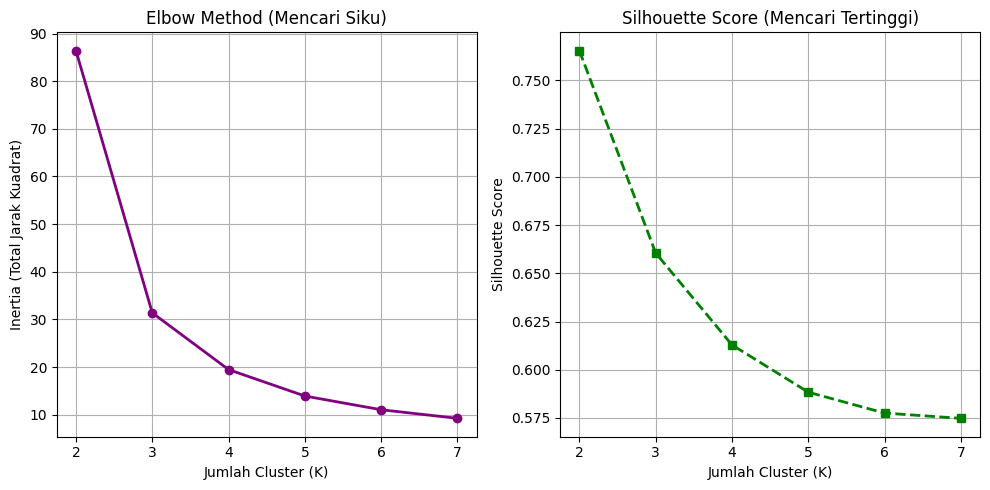

In [ ]:
# Visualisasi Grafik Garis (Elbow Method)
plt.figure(figsize=(10, 5))

# Plot Inertia (Elbow)
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o', linestyle='-', color='purple', linewidth=2)
plt.title('Elbow Method (Mencari Siku)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia (Total Jarak Kuadrat)')
plt.grid(True)

# Plot Silhouette Score (Opsional, untuk penguatan)
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='s', linestyle='--', color='green', linewidth=2)
plt.title('Silhouette Score (Mencari Tertinggi)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

Grafik Elbow dan Silhouette Score ditampilkan untuk melihat jumlah cluster terbaik. Biasanya titik siku pada grafik menunjukkan jumlah cluster yang optimal.

In [ ]:
#2PROFILING & PENAMAAN SEGMEN (TUGAS 2 & 3)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
df = pd.DataFrame(X, columns=['Petal_Length', 'Petal_Width'])
df['Cluster'] = labels

profil = df.groupby('Cluster').mean().round(2)
print(profil)
print("-" * 50)

nama_segmen = {
    0: "Bunga Kecil (Tipe Setosa)",
    1: "Bunga Besar (Tipe Virginica)",
    2: "Bunga Sedang (Tipe Versicolor)"
}
df['Segmen'] = df['Cluster'].map(nama_segmen)
print(df[['Cluster', 'Segmen']].drop_duplicates().sort_values('Cluster').to_string(index=False))
print("-" * 50)

         Petal_Length  Petal_Width
Cluster                           
0                5.60         2.04
1                1.46         0.25
2                4.27         1.34
--------------------------------------------------
 Cluster                         Segmen
       0      Bunga Kecil (Tipe Setosa)
       1   Bunga Besar (Tipe Virginica)
       2 Bunga Sedang (Tipe Versicolor)
--------------------------------------------------


Pada bagian ini dilakukan proses clustering menggunakan algoritma K-Means dengan jumlah cluster sebanyak 3. Setiap data kemudian diberikan label cluster.

kemudian program menampilkan rata-rata setiap fitur pada masing-masing cluster. Hal ini digunakan untuk melihat karakteristik dari setiap kelompok data.

pada bagian ini juga setiap cluster diberi nama segmen agar hasil pengelompokkan lebih mudah untuk dipahami.


In [ ]:
#REKOMENDASI BISNIS

print("\n--- REKOMENDASI BISNIS ---")
print("1. Target Bunga Kecil: Pasarkan sebagai buket bunga meja kecil dengan harga terjangkau untuk mahasiswa.")
print("2. Target Bunga Sedang: Stok paling banyak harus di segmen ini karena ukurannya yang paling diminati pasar umum.")
print("3. Target Bunga Besar: Berikan kemasan eksklusif dan targetkan untuk hadiah mewah atau dekorasi pernikahan.")


--- REKOMENDASI BISNIS ---
1. Target Bunga Kecil: Pasarkan sebagai buket bunga meja kecil dengan harga terjangkau untuk mahasiswa.
2. Target Bunga Sedang: Stok paling banyak harus di segmen ini karena ukurannya yang paling diminati pasar umum.
3. Target Bunga Besar: Berikan kemasan eksklusif dan targetkan untuk hadiah mewah atau dekorasi pernikahan.


Pada bagian ini berdasarkan hasil clustering, dibuat beberapa rekomendasi strategi bisnis untuk setiap segmen bunga agar pemasaran lebih tepat sasaran.